In [2]:
import os
import pandas as pd
import psycopg2

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

import warnings
warnings.filterwarnings('ignore')

load_dotenv(".env")

True

In [104]:
def connect_to_db():
    try:
        conn = psycopg2.connect(
            host="localhost",
            port=os.getenv("DB_PORT", 5432),
            database=os.getenv("DB_NAME", "online_store"),
            user=os.getenv("DB_USER", "postgres"),
            password=os.getenv("DB_PASSWORD", "postgres")
        )
        print("Успешное подключение к базе данных")
        return conn
    except Exception as e:
        print(f"Ошибка подключения: {e}")
        return None

conn = connect_to_db()

Успешное подключение к базе данных


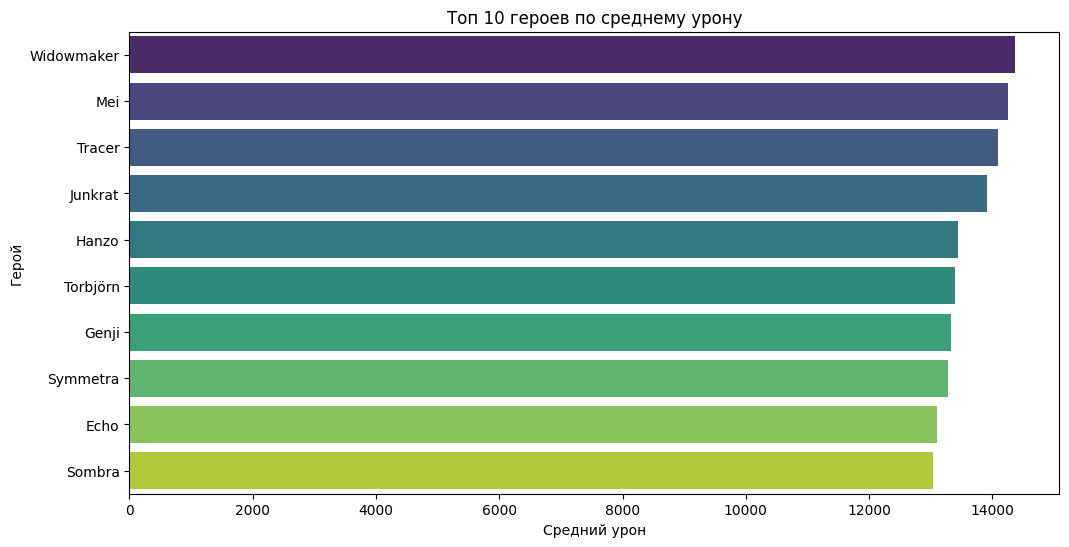

In [105]:
query = """
SELECT h.name AS hero_name,
       AVG(mp.damage) AS avg_damage,
       COUNT(mp.id) AS games_played
FROM match_players mp
JOIN heroes h ON mp.hero_id = h.id
GROUP BY h.name
HAVING COUNT(mp.id) > 10
ORDER BY avg_damage DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df, x="avg_damage", y="hero_name", palette="viridis")
plt.xlabel("Средний урон")
plt.ylabel("Герой")
plt.title("Топ 10 героев по среднему урону")
plt.show()


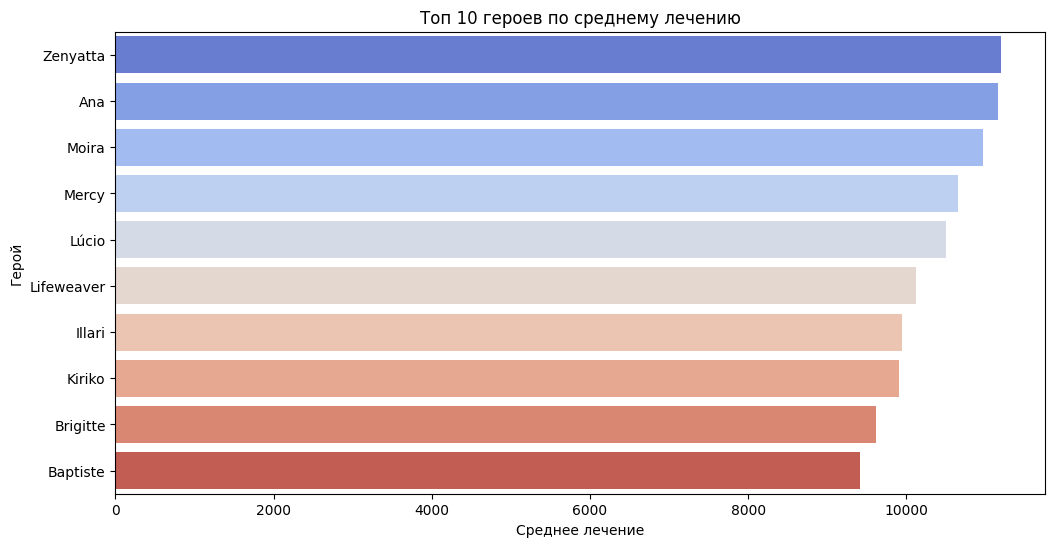

In [106]:
query = """
SELECT h.name AS hero_name,
       AVG(mp.healing) AS avg_healing,
       COUNT(mp.id) AS games_played
FROM match_players mp
JOIN heroes h ON mp.hero_id = h.id
GROUP BY h.name
HAVING COUNT(mp.id) > 10
ORDER BY avg_healing DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df, x="avg_healing", y="hero_name", palette="coolwarm")
plt.xlabel("Среднее лечение")
plt.ylabel("Герой")
plt.title("Топ 10 героев по среднему лечению")
plt.show()


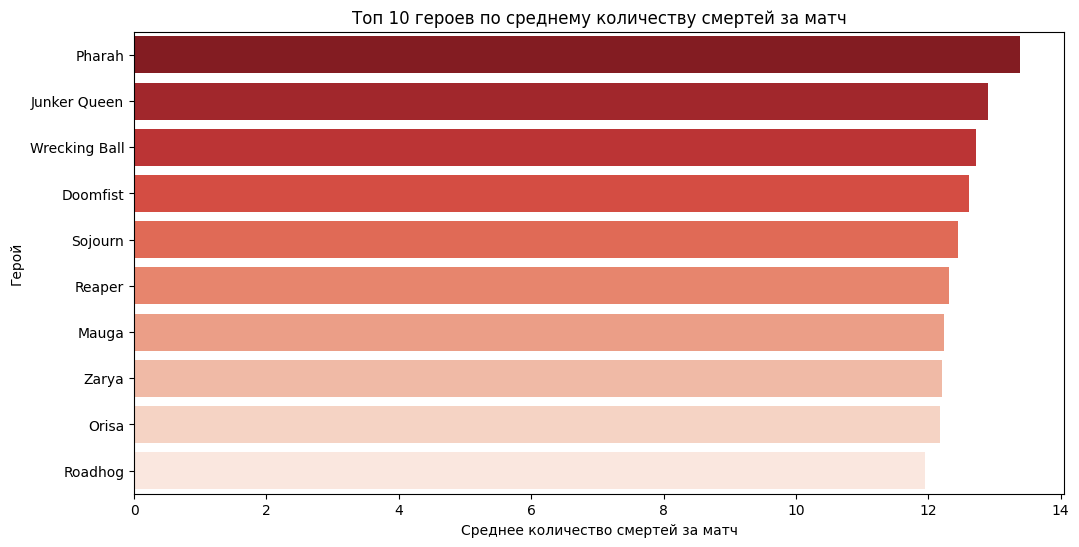

In [ ]:
query = """
SELECT h.name AS hero_name,
       AVG(mp.deaths) AS avg_deaths_per_match,
       COUNT(mp.id) AS games_played
FROM match_players mp
JOIN heroes h ON mp.hero_id = h.id
GROUP BY h.name
HAVING COUNT(mp.id) > 10
ORDER BY avg_deaths_per_match DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df, x="avg_deaths_per_match", y="hero_name", palette="Reds_r")
plt.xlabel("Среднее количество смертей за матч")
plt.ylabel("Герой")
plt.title("Топ 10 героев по среднему количеству смертей за матч")
plt.show()
